# ARTI308 - Machine Learning
## Lab 6 Task: Linear Regression on Ecommerce Customers Dataset

In this task, we apply Linear Regression to the **Ecommerce Customers** dataset to predict the **Yearly Amount Spent** by customers based on their behaviour metrics.

---
## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

%matplotlib inline

---
## Step 2: Load and Explore the Data

In [2]:
df = pd.read_csv('Ecommerce_Customers.csv')
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [4]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


**Dataset Overview:**
- 500 rows and 8 columns
- Columns: `Email`, `Address`, `Avatar` (categorical/text), and 5 numerical columns
- Target variable: `Yearly Amount Spent`
- No missing values detected

---
## Step 3: Data Cleaning

In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64


In [6]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


**Cleaning Result:** The dataset is clean — no missing values or duplicate rows. The columns `Email`, `Address`, and `Avatar` are text/categorical and will be dropped since they carry no predictive numerical information.

---
## Step 4: Exploratory Data Analysis (EDA)

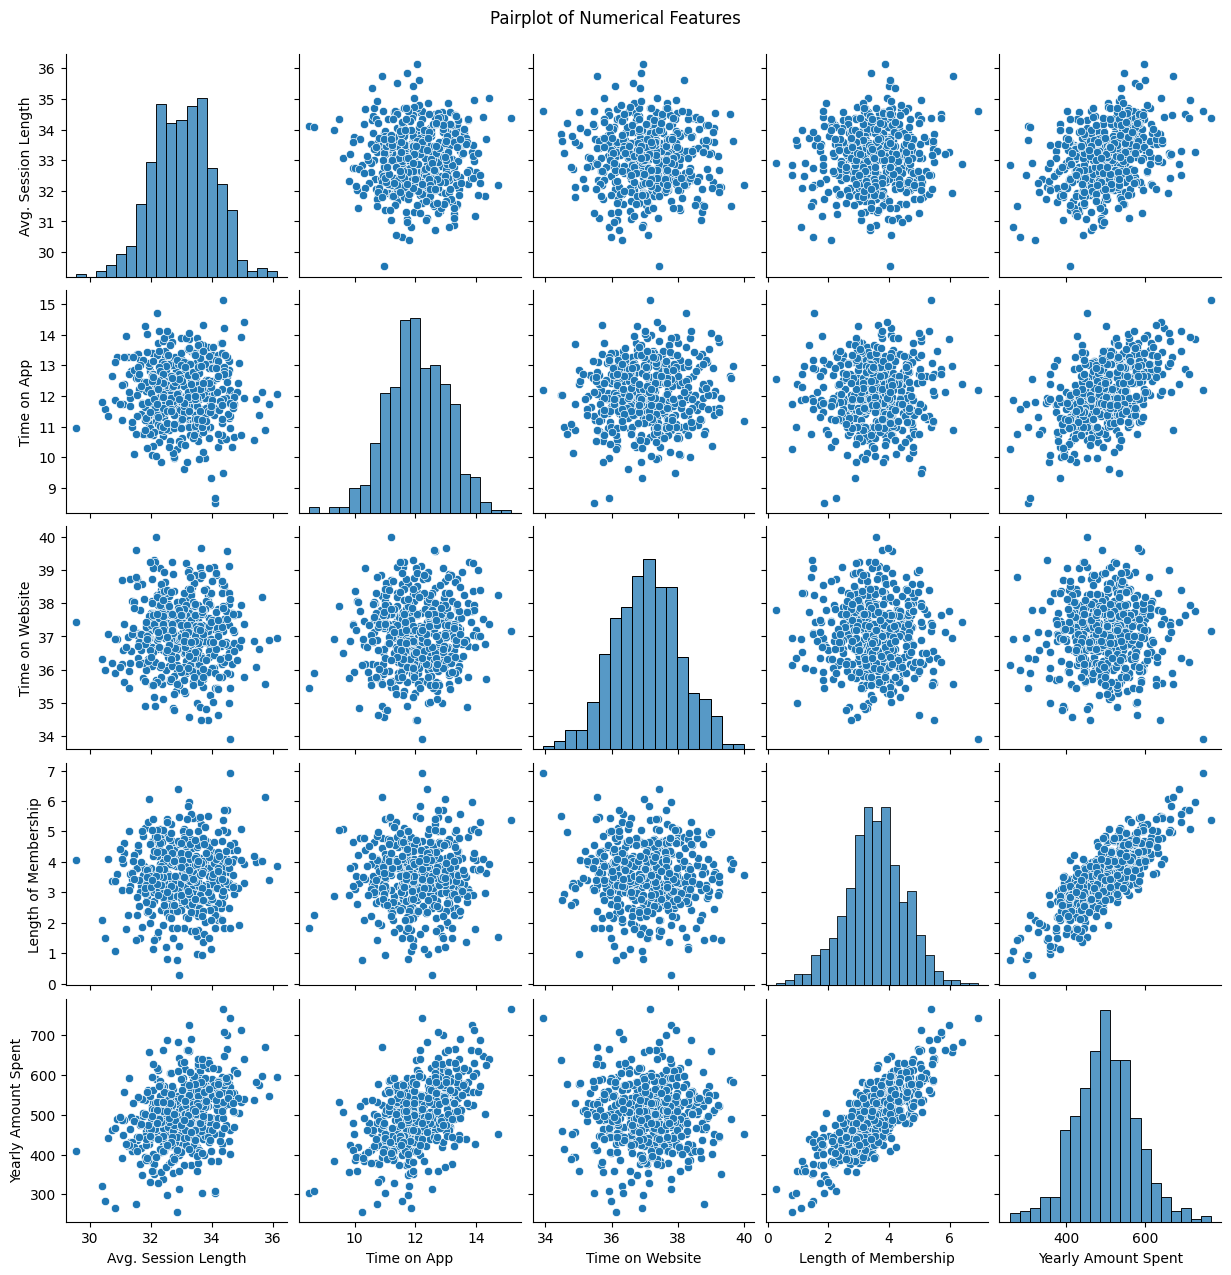

In [7]:
# Select only numerical columns for EDA
numerical_cols = ['Avg. Session Length', 'Time on App', 'Time on Website',
                  'Length of Membership', 'Yearly Amount Spent']

sns.pairplot(df[numerical_cols])
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

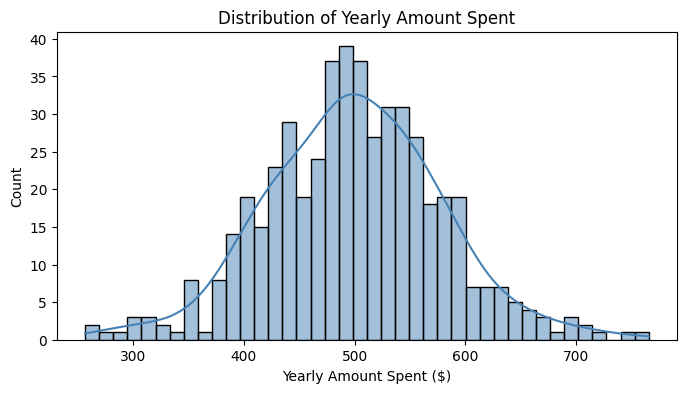

In [8]:
# Distribution of the target variable
plt.figure(figsize=(8, 4))
sns.histplot(df['Yearly Amount Spent'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Yearly Amount Spent')
plt.xlabel('Yearly Amount Spent ($)')
plt.show()

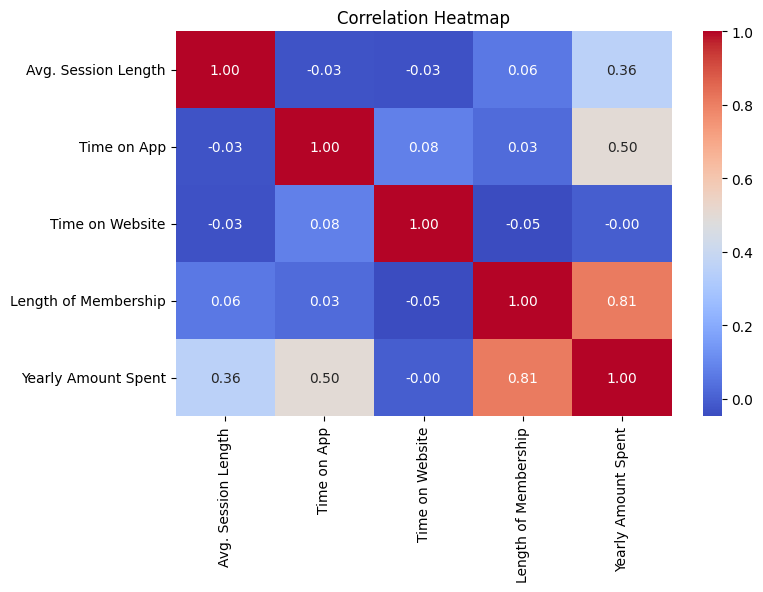

In [9]:
# Correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**EDA Observations:**
- `Length of Membership` has the **strongest correlation** with `Yearly Amount Spent`
- `Time on App` also shows a strong positive relationship with the target
- `Time on Website` has very little correlation with spending — interesting!
- The target variable is approximately **normally distributed**

---
## Step 5: Feature Engineering & Data Preparation

In [10]:
# Drop non-numerical columns — they cannot be used by Linear Regression
# No additional feature engineering needed; features are already on comparable scales

X = df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = df['Yearly Amount Spent']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (500, 4)
Target vector shape: (500,)


---
## Step 6: Train/Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size:     {X_test.shape[0]} samples")

Training set size: 350 samples
Test set size:     150 samples


---
## Step 7: Train the Linear Regression Model

In [12]:
lm = LinearRegression()
lm.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Intercept: {lm.intercept_:.4f}")

Model trained successfully!
Intercept: -1047.9328


In [13]:
# Display coefficients
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Session Length,25.981550
Time on App,38.590159
Time on Website,0.190405
Length of Membership,61.279097


**Interpreting the Coefficients:**

- Holding all other features fixed, a 1-unit increase in **Avg. Session Length** is associated with an increase of **~$25.98** in yearly spending.
- Holding all other features fixed, a 1-unit increase in **Time on App** is associated with an increase of **~$38.59** in yearly spending.
- Holding all other features fixed, a 1-unit increase in **Time on Website** is associated with an increase of only **~$0.19** — almost negligible.
- Holding all other features fixed, a 1-unit increase in **Length of Membership** is associated with an increase of **~$61.28** in yearly spending — the most impactful feature!

> **Business Insight:** The company should focus on increasing customer **membership tenure** and **app engagement**, as these drive the most revenue.

---
## Step 8: Predictions & Model Evaluation

In [14]:
predictions = lm.predict(X_test)

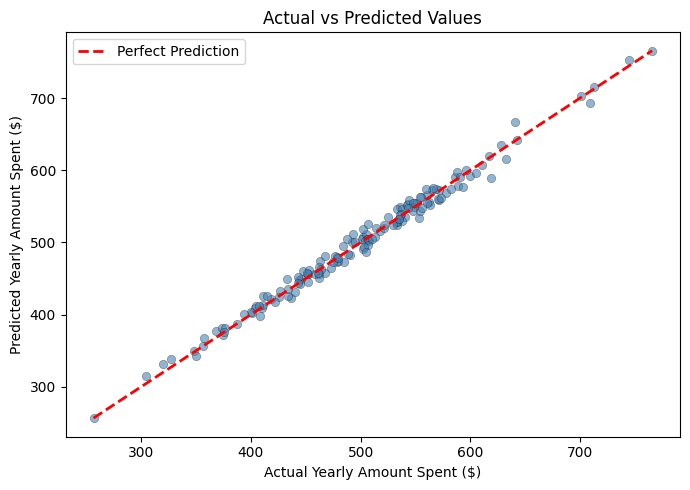

In [15]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, predictions, alpha=0.6, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yearly Amount Spent ($)')
plt.ylabel('Predicted Yearly Amount Spent ($)')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.tight_layout()
plt.show()

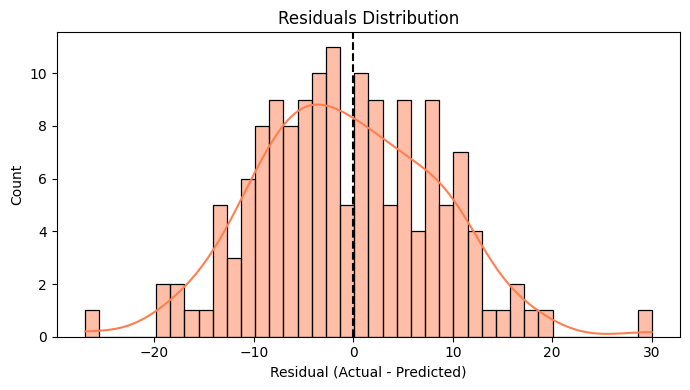

In [16]:
# Residuals distribution
residuals = y_test - predictions

plt.figure(figsize=(7, 4))
sns.histplot(residuals, bins=40, kde=True, color='coral')
plt.title('Residuals Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

**Residuals look normally distributed and centred around 0** — a good sign that the linear model assumptions are satisfied.

In [17]:
mae  = metrics.mean_absolute_error(y_test, predictions)
mse  = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print(f"MAE  (Mean Absolute Error):      ${mae:.2f}")
print(f"MSE  (Mean Squared Error):        {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):  ${rmse:.2f}")

MAE  (Mean Absolute Error):      $7.23
MSE  (Mean Squared Error):        79.81
RMSE (Root Mean Squared Error):  $8.93


---
## Conclusion

| Metric | Value |
|--------|-------|
| MAE    | $7.23 |
| MSE    | 79.81 |
| RMSE   | $8.93 |

The model performs **very well**:
- The average prediction error is only **~$8.93** on a target that ranges from ~$257 to ~$766.
- The Actual vs Predicted scatter plot shows points tightly clustered along the ideal diagonal line.
- Residuals are normally distributed and centred around zero, confirming the model is a good fit.

**Key Takeaway:** `Length of Membership` and `Time on App` are the most influential features in predicting yearly customer spending. The company would benefit most from strategies that improve customer retention and in-app engagement.